# Chronic kIdney Disease Data Ingestion


This notebook loads in the data from the chronic kidney disease dataset (dataset 3) into a pandas dataframe and performs basic data cleaning and validation

In [1]:
#Required libraries
import os

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

print("All libraries successfully retrieved.")

All libraries successfully retrieved.


In [2]:
path = "../../data/raw/dataset_2.csv"

try:
    CKD_df = pd.read_csv(path)
except Exception as e:
    print("Error: ", e)

print(f"File: {path} loaded successfully \n")
CKD_df.head(5)

File: ../../data/raw/dataset_2.csv loaded successfully 



,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


### Give a breakdown of all nulls present


In [3]:
print('Standard NaN missing values:')
print(CKD_df.isnull().sum())

Standard NaN missing values:
Bp       0
Sg       0
Al       0
Su       0
Rbc      0
Bu       0
Sc       0
Sod      0
Pot      0
Hemo     0
Wbcc     0
Rbcc     0
Htn      0
Class    0
dtype: int64


### Lets Get An Idea of the Initial Classifications For Chronic Kidney Disease

In [4]:
#Overview of the distribution of CKD in the dataset
print('Chronic Kidney Disease distribution:')
print(CKD_df['Class'].value_counts())
print()
print('Proportions:')
print(CKD_df['Class'].value_counts(normalize=True).round(4))


Chronic Kidney Disease distribution:
Class
1    250
0    150
Name: count, dtype: int64

Proportions:
Class
1    0.625
0    0.375
Name: proportion, dtype: float64


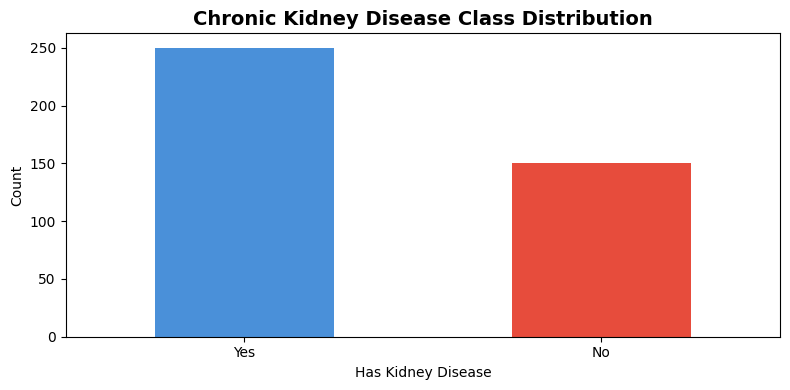

In [5]:
# Visualize class balance
fig, ax = plt.subplots(figsize=(8, 4))
CKD_df['Class'].value_counts().plot(kind='bar', color=['#4A90D9', '#E74C3C'], ax=ax)

ax.set_xticklabels(['Yes', 'No'], rotation=0)

ax.set_title('Chronic Kidney Disease Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Has Kidney Disease')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## Data Preprocessing

In [6]:
#We have no NaNs but still include incase of changes to dataset or updated dataset being loaded in

#Replace any NaNs with ? for proper processing by sk learn
CKD_df = CKD_df.replace('?', np.nan)

# Check missing value percentages
print("Missing values replaced with '?'")
print(f'Total rows affected: {CKD_df.isnull().any(axis=1).sum()}')

Missing values replaced with '?'
Total rows affected: 0


In [ ]:
# Standardize column name
CKD_df = CKD_df.rename(columns={"Bp": "bp",
    "Sg": "sg",
    "Al": "al",
    "Su": "su",
    "Rbc": "rbc",
    "Bu": "bu",
    "Sc": "sc",
    "Sod": "sod",
    "Pot": "pot",
    "Hemo": "hemo",
    "Wbcc": "wc",
    "Rbcc": "rc",
    "Htn": "htn",
    "Class": "target"})

print("Unique target values before mapping:")
print(CKD_df['target'].unique())

Unique target values before mapping:
[1 0]


In [8]:
#Final target distribution after mapping
print("Final target distribution:")
print(CKD_df['target'].value_counts())

Final target distribution:
target
1    250
0    150
Name: count, dtype: int64


In [9]:
import os

path = "../../data/cleaned/dataset_2"
os.makedirs(path, exist_ok=True)

# Save cleaned dataset
CKD_df.to_csv(f"{path}/dataset_2_clean.csv", index=False)

print(f"Cleaned Dataset 2 saved to: {path}/dataset_2_clean.csv")
print("Shape:", CKD_df.shape)
print("Columns:", CKD_df.columns.tolist())

Cleaned Dataset 2 saved to: ../../data/cleaned/dataset_2/dataset_2_clean.csv
Shape: (400, 14)
Columns: ['bp', 'sg', 'al', 'su', 'rbc', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc', 'rc', 'htn', 'target']
